In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import xarray as xr

import sys
import pathlib
sys.path.append(str(pathlib.Path.cwd().parent.parent))
import ISRUtilities as isru
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAUnits'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/find_deltas.batch'
do_save = False

In [2]:
def corticalDownStates(session,n=1,silence=0.12):
    # n : number of allowed delta spikes

    R = fma.regions.regions(session,states='sws')
    events = isru.loadHpcPfcEvents(session,names=['ripples','down','deltaWaves'],regions=R)

    spikes = R.spikes(regs='pfc')[:,0]
    down, fr = fma.preprocess.corticalDownStates(spikes,n=n,silence=silence,return_fr=True)
    fr[:,1:] /= len(R.units('pfc'))

    intervals = np.mean(down,axis=1,keepdims=True)[:100] + [-0.4,0.4]
    lfp = fma.data.loadWideband(session,channels=R.channels('pfc')[7],intervals=intervals,skip=50,cat=False)

    fr = xr.DataArray(fr,dims=['t','val'],coords={'rat': R.basename, 'n': len(R.units('pfc'))})

    return fr, events, down, lfp, R.eventIntervals('sws')

In [3]:
# test on one session
# 51: Rat005_20240529, 129 u, n 1, s 0.12
# 52: Rat005_20240603, 196 u, n 1, s 0.12
# 53: Rat005_20240610, 202 u, n 1, s 0.12
session = fma.data.readBatchFile(batch_file)[0][16] # 51, 52, 53
print(session)
n = 1
sil = 0.12
fr, events, down, lfp, sws = corticalDownStates(session,n=n,silence=sil)
durations = np.diff(down).ravel()

/mnt/hubel-data-139/karadoc/Rat004_20240228/Rat004_20240228.xml


In [4]:
# for Raly
#from scipy.io import savemat
#savemat(f"{fr.rat.values}_spikes.mat", {"spikes_pfc": spikes_pfc, "spikes_hpc": spikes_hpc})

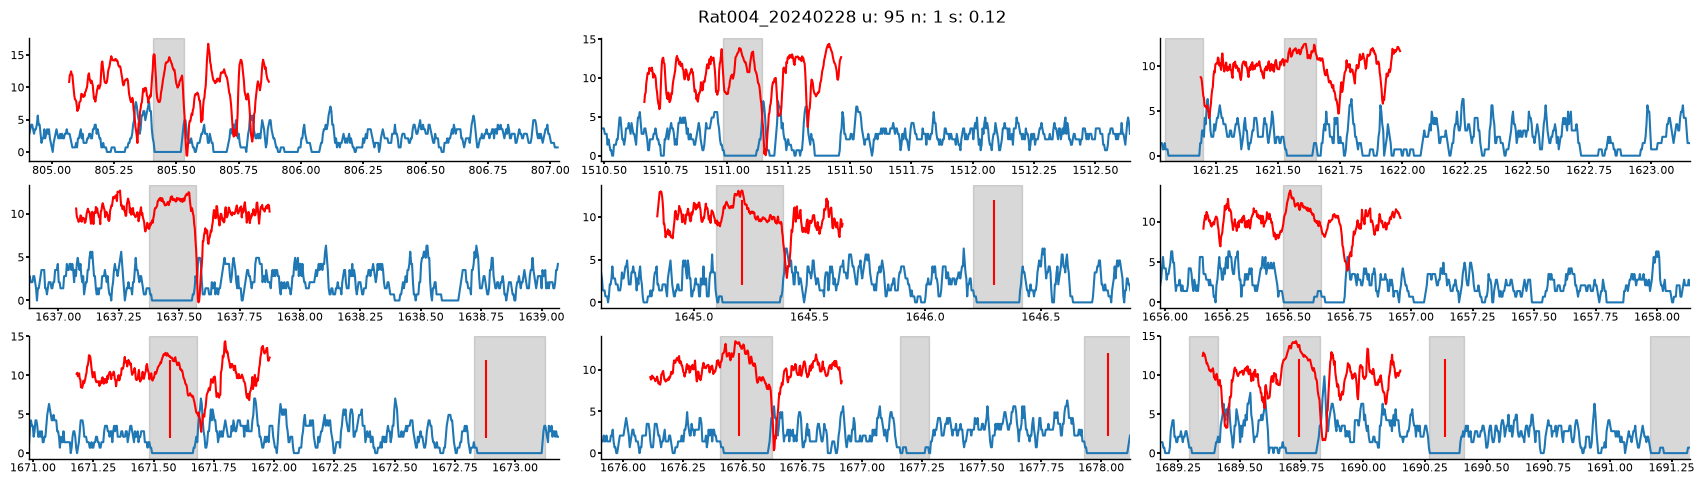

In [7]:
fig, ax = fma.plotting.makeFigure(f'{fr.rat.values} u: {fr.n.values} n: {n} s: {sil}',size=(43,12), n=(3,3))
to_plot = np.sort(np.random.choice(len(lfp[0]),size=ax.size,replace=False))
for i, p in enumerate(to_plot):
    j, k = np.unravel_index(i,ax.shape)
    start = down[p,0] - 0.5
    stop = down[p,1] + 1.5

    fma.plotting.plotXY(fr,start=start,stop=stop,ax=ax[j,k])
    p_min = max(p-3,0)
    fma.plotting.plotIntervals(down[p_min:p+4],ax=ax[j,k])
    fma.plotting.plotRaster(events['deltaWaves'],height=10,offset=7,color='r',ax=ax[j,k])
    if len(lfp):
        ax[j,k].plot(lfp[1][p],lfp[0][p]/500+10,color='r')

    ax[j,k].set(xlim=[start,stop])

test jointPETH relations, could be recovered using HPC bursts!

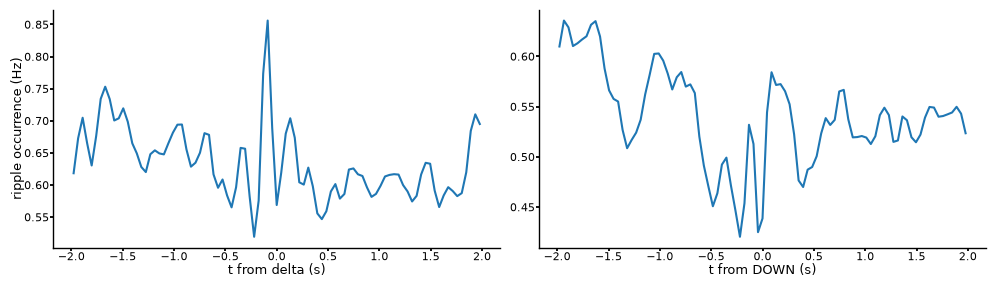

In [6]:
fig, ax = fma.plotting.makeFigure(size=(25,7), n=(1,2))

_, t, m = fma.analysis.PETH(events['ripples'],events['deltaWaves'],limits=(-2,2),n_bins=91,smooth=1)
ax[0].plot(t,m/(t[1]-t[0]))
ax[0].set(xlabel='t from delta (s)',ylabel='ripple occurrence (Hz)')

_, t, m = fma.analysis.PETH(events['ripples'],np.mean(down,axis=1),limits=(-2,2),n_bins=91,smooth=1)
ax[1].plot(t,m/(t[1]-t[0]))
ax[1].set(xlabel='t from DOWN (s)');

see some ripples

In [8]:
def loadExamples(session,channel=None):
    R = fma.regions.regions(session,load_spikes=False)
    events = isru.loadHpcPfcEvents(session)

    regs = ['hpc','pfc','pfc']
    names = ['ripples','spindles','deltaWaves']
    if channel is None:
        channel = {names[i]: R.channels(r)[8] for i, r in enumerate(regs)}
    limits = [[-1,1],[-1,1],[-5,5]]
    skip = [20,100,600]

    rng = np.random.default_rng()
    examples = {}
    for i, e in enumerate(events):
        print(f'{e}: {channel[e]}')

        intervals = np.sort(rng.choice(events[e],size=5,replace=False,shuffle=False)[:,None],axis=0) + limits[i] if len(events[e]) else []
        ex = fma.data.loadWideband(session,intervals=intervals,channels=channel[e],skip=skip[i],cat=False,trim=True)
        examples[e] = {}
        examples[e]['data'] = np.hstack(ex[0])
        examples[e]['t'] = np.stack(ex[1],axis=1)

    return examples

In [9]:
examples = loadExamples(session,channel={'ripples': 74, 'spindles': 35, 'deltaWaves': 35}) # perceval
#examples = loadExamples(session,channel={'ripples': 145, 'spindles': 126, 'deltaWaves': 126}) # peter

ripples: 74
deltaWaves: 35
spindles: 35


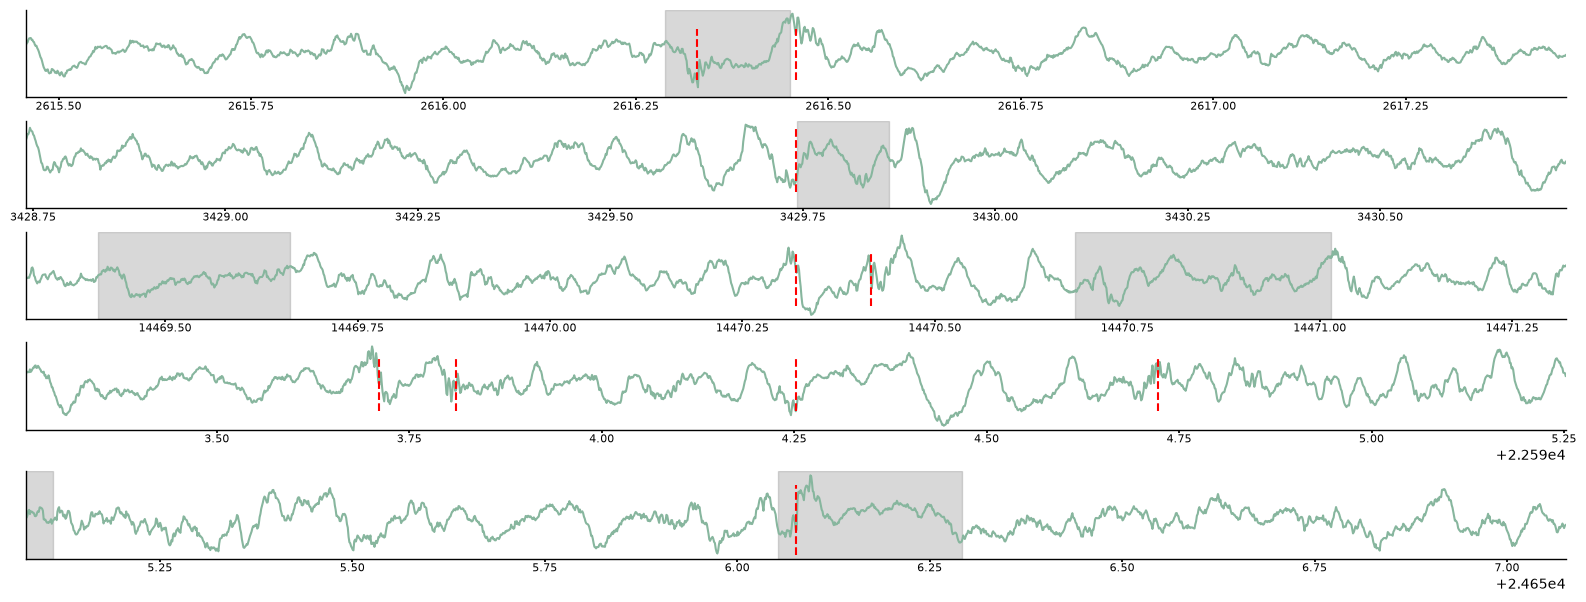

In [10]:
name = 'ripples'
fig, ax = fma.plotting.makeFigure(n=(5,1),size=(40,15))
for i in range(examples[name]['data'].shape[1]):
    start = examples[name]['t'][0,i]
    stop = examples[name]['t'][-1,i]
    mid = examples[name]['t'][len(examples[name]['t'])//2,:]
    ax[i].plot(examples[name]['t'][:,i],examples[name]['data'][:,i]/1000,color=isru.paperColors(name))
    fma.plotting.plotRaster(events[name],height=6,offset=0,color='r',ls='--',ax=ax[i]) # filtered
    #fma.plotting.plotRaster(events[name],height=2,offset=1,color='r',ls='--',ax=ax[i]) # peter
    fma.plotting.plotIntervals(down,ax=ax[i])
    ax[i].set(xlim=[start,stop],yticks=[])